In [1]:
# ============================================================
# FUNCTION 8 — WEEK 6 CLEAN, MEMORY-SAFE REBUILD
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.spatial import cKDTree

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel
)

# ------------------------------------------------------------
# 1. Load original Function 8 data
# ------------------------------------------------------------

X = np.load("function8/initial_inputs.npy")
Y = np.load("function8/initial_outputs.npy").reshape(-1)

# ------------------------------------------------------------
# 2. Add Weeks 1–5 exactly once
# ------------------------------------------------------------

weekly_X = np.array([
    [0.344451, 0.156410, 0.006670, 0.033817,
     0.853859, 0.614858, 0.045559, 0.106726],

    [0.147947, 0.193825, 0.060981, 0.008004,
     0.719306, 0.453461, 0.045592, 0.938970],

    [0.129113, 0.207318, 0.165052, 0.244138,
     0.603646, 0.535759, 0.168630, 0.681517],

    [0.078500, 0.107318, 0.212619, 0.144138,
     0.703646, 0.485325, 0.134507, 0.581517],

    [0.094000, 0.176776, 0.102226, 0.140555,
     0.983809, 0.566369, 0.157956, 0.568035]
])

weekly_Y = np.array([
    9.7346382479349,
    9.894432442301,
    9.9592828135141,
    9.9632714558391,
    9.971872362175
])

X = np.vstack([X, weekly_X])
Y = np.concatenate([Y, weekly_Y])

best_index = np.argmax(Y)
best_x = X[best_index]
best_y = Y[best_index]

print("Week 6 X shape:", X.shape)
print("Week 6 Y shape:", Y.shape)

print("\nBest observed input:")
print(best_x)

print("Best observed output:")
print(best_y)

print("\nWeek 5 input:")
print(weekly_X[-1])

print("Week 5 output:")
print(weekly_Y[-1])

Week 6 X shape: (45, 8)
Week 6 Y shape: (45,)

Best observed input:
[0.094    0.176776 0.102226 0.140555 0.983809 0.566369 0.157956 0.568035]
Best observed output:
9.971872362175

Week 5 input:
[0.094    0.176776 0.102226 0.140555 0.983809 0.566369 0.157956 0.568035]
Week 5 output:
9.971872362175


In [2]:
# ============================================================
# 3. FIT ARD GAUSSIAN PROCESS
# ============================================================

kernel = (
    C(1.0, (1e-3, 1e3))
    *
    Matern(
        length_scale=np.full(8, 0.40),
        length_scale_bounds=(0.02, 4.0),
        nu=2.5
    )
    +
    WhiteKernel(
        noise_level=1e-6,
        noise_level_bounds=(1e-10, 1e-2)
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=7,
    random_state=68
)

gp.fit(X, Y)

print("Fitted kernel:")
print(gp.kernel_)

lengthscales = np.asarray(
    gp.kernel_.k1.k2.length_scale
)

importance = 1 / lengthscales
importance = importance / importance.sum()

print("\nFitted lengthscales:")
print(lengthscales)

print("\nNormalised input influence:")

for i, value in enumerate(importance, start=1):
    print(f"x{i}: {value:.4f}")

Fitted kernel:
1.68**2 * Matern(length_scale=[1.99, 2.89, 1.55, 4, 4, 4, 2.06, 4], nu=2.5) + WhiteKernel(noise_level=1e-10)

Fitted lengthscales:
[1.99406508 2.88735262 1.55315486 4.         4.         4.
 2.0646836  4.        ]

Normalised input influence:
x1: 0.1685
x2: 0.1164
x3: 0.2163
x4: 0.0840
x5: 0.0840
x6: 0.0840
x7: 0.1627
x8: 0.0840


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 4.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 4.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 4.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/co

In [3]:
# ============================================================
# 3. FIT ARD GAUSSIAN PROCESS
# ============================================================

kernel = (
    C(1.0, (1e-3, 1e3))
    *
    Matern(
        length_scale=np.full(8, 0.40),
        length_scale_bounds=(0.02, 4.0),
        nu=2.5
    )
    +
    WhiteKernel(
        noise_level=1e-6,
        noise_level_bounds=(1e-10, 1e-2)
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=7,
    random_state=68
)

gp.fit(X, Y)

print("Fitted kernel:")
print(gp.kernel_)

lengthscales = np.asarray(
    gp.kernel_.k1.k2.length_scale
)

importance = 1 / lengthscales
importance = importance / importance.sum()

print("\nFitted lengthscales:")
print(lengthscales)

print("\nNormalised input influence:")

for i, value in enumerate(importance, start=1):
    print(f"x{i}: {value:.4f}")

Fitted kernel:
1.68**2 * Matern(length_scale=[1.99, 2.89, 1.55, 4, 4, 4, 2.06, 4], nu=2.5) + WhiteKernel(noise_level=1e-10)

Fitted lengthscales:
[1.99406508 2.88735262 1.55315486 4.         4.         4.
 2.0646836  4.        ]

Normalised input influence:
x1: 0.1685
x2: 0.1164
x3: 0.2163
x4: 0.0840
x5: 0.0840
x6: 0.0840
x7: 0.1627
x8: 0.0840


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 4.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 4.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 4.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/co

In [5]:
# ============================================================
# 4. WEEK 6 CANDIDATE GENERATION
# ============================================================

rng = np.random.default_rng(68)

week5_point = np.array([
    0.094000, 0.176776, 0.102226, 0.140555,
    0.983809, 0.566369, 0.157956, 0.568035
])

week4_point = np.array([
    0.078500, 0.107318, 0.212619, 0.144138,
    0.703646, 0.485325, 0.134507, 0.581517
])

week3_point = np.array([
    0.129113, 0.207318, 0.165052, 0.244138,
    0.603646, 0.535759, 0.168630, 0.681517
])

# ------------------------------------------------------------
# A. Very local around new Week 5 best
# ------------------------------------------------------------

very_local = rng.normal(
    loc=week5_point,
    scale=[
        0.010, 0.012, 0.012, 0.012,
        0.015, 0.015, 0.012, 0.015
    ],
    size=(7_000, 8)
)

# ------------------------------------------------------------
# B. Local around Week 5
# ------------------------------------------------------------

local_week5 = rng.normal(
    loc=week5_point,
    scale=[
        0.025, 0.030, 0.030, 0.030,
        0.040, 0.035, 0.030, 0.040
    ],
    size=(8_000, 8)
)

# ------------------------------------------------------------
# C. Local around Week 4
# ------------------------------------------------------------

local_week4 = rng.normal(
    loc=week4_point,
    scale=[
        0.025, 0.030, 0.030, 0.030,
        0.045, 0.035, 0.030, 0.040
    ],
    size=(5_000, 8)
)

# ------------------------------------------------------------
# D. Blend Week 4 and Week 5
# ------------------------------------------------------------

weights_45 = rng.uniform(
    0,
    1,
    size=(5_000, 1)
)

blend_45 = (
    weights_45 * week5_point
    +
    (1 - weights_45) * week4_point
)

blend_45 += rng.normal(
    0,
    [
        0.012, 0.015, 0.015, 0.015,
        0.020, 0.018, 0.015, 0.020
    ],
    size=(5_000, 8)
)

# ------------------------------------------------------------
# E. Blend Week 3 and Week 5
# ------------------------------------------------------------

weights_35 = rng.uniform(
    0.55,
    1.0,
    size=(4_000, 1)
)

blend_35 = (
    weights_35 * week5_point
    +
    (1 - weights_35) * week3_point
)

blend_35 += rng.normal(
    0,
    [
        0.012, 0.015, 0.015, 0.015,
        0.020, 0.018, 0.015, 0.020
    ],
    size=(4_000, 8)
)

candidates = np.vstack([
    very_local,
    local_week5,
    local_week4,
    blend_45,
    blend_35
])

candidates = np.clip(
    candidates,
    0,
    1
)

print(
    "Candidates before filtering:",
    len(candidates)
)

Candidates before filtering: 29000


In [6]:
# ============================================================
# 5. REMOVE NEAR-DUPLICATES
# ============================================================

tree = cKDTree(X)

minimum_distance, _ = tree.query(
    candidates,
    k=1
)

keep = (
    minimum_distance > 0.005
)

candidates = candidates[keep]

print(
    "Candidates after filtering:",
    len(candidates)
)

Candidates after filtering: 29000


In [7]:
# ============================================================
# 6. PREDICT IN BATCHES
# ============================================================

def predict_in_batches(
    model,
    points,
    batch_size=1500
):

    means = []
    standard_deviations = []

    for start in range(
        0,
        len(points),
        batch_size
    ):

        batch = points[
            start:start + batch_size
        ]

        batch_mean, batch_std = model.predict(
            batch,
            return_std=True
        )

        means.append(batch_mean)
        standard_deviations.append(batch_std)

    return (
        np.concatenate(means),
        np.concatenate(standard_deviations)
    )

mean, std = predict_in_batches(
    gp,
    candidates,
    batch_size=1500
)

In [8]:
# ============================================================
# 7. EXPECTED IMPROVEMENT
# ============================================================

xi = 0.001

improvement = (
    mean
    - best_y
    - xi
)

with np.errstate(
    divide="ignore",
    invalid="ignore"
):

    z = improvement / std

    ei = (
        improvement * norm.cdf(z)
        +
        std * norm.pdf(z)
    )

ei[std < 1e-12] = 0


# ------------------------------------------------------------
# Small UCB component
# ------------------------------------------------------------

kappa = 0.30

ucb = (
    mean
    + kappa * std
)

In [9]:
# ============================================================
# 8. FILTER WEAK PREDICTIONS
# ============================================================

mean_filter = (
    mean >= best_y - 0.05
)

if mean_filter.sum() < 100:

    mean_filter = (
        mean >= np.percentile(
            mean,
            90
        )
    )

filtered_candidates = candidates[
    mean_filter
]

filtered_mean = mean[
    mean_filter
]

filtered_std = std[
    mean_filter
]

filtered_ei = ei[
    mean_filter
]

filtered_ucb = ucb[
    mean_filter
]

print(
    "Candidates passing mean filter:",
    len(filtered_candidates)
)

Candidates passing mean filter: 28743


In [10]:
# ============================================================
# 9. ACQUISITION SCORE
# ============================================================

ei_norm = (
    filtered_ei
    - filtered_ei.min()
) / (
    np.ptp(filtered_ei)
    + 1e-12
)

ucb_norm = (
    filtered_ucb
    - filtered_ucb.min()
) / (
    np.ptp(filtered_ucb)
    + 1e-12
)

# Week 5 is now the best,
# so strongly favour local exploitation.
acquisition = (
    0.90 * ei_norm
    +
    0.10 * ucb_norm
)

chosen_index = np.argmax(
    acquisition
)

week6_query = filtered_candidates[
    chosen_index
]

In [13]:
# ============================================================
# 10. FUNCTION 8 — WEEK 6 PORTAL OUTPUT
# ============================================================

print("\nSuggested Week 6 query:")
print(week6_query)

print("\nPortal format:")
print(
    "-".join(
        f"{value:.6f}"
        for value in week6_query
    )
)

print(
    "\nPredicted mean:",
    filtered_mean[chosen_index]
)

print(
    "Predicted uncertainty:",
    filtered_std[chosen_index]
)

print(
    "Expected Improvement:",
    filtered_ei[chosen_index]
)

print(
    "UCB:",
    filtered_ucb[chosen_index]
)

print(
    "Distance from Week 5:",
    np.linalg.norm(
        week6_query
        - week5_point
    )
)

print(
    "Distance from Week 4:",
    np.linalg.norm(
        week6_query
        - week4_point
    )
)

print(
    "Distance from Week 3:",
    np.linalg.norm(
        week6_query
        - week3_point
    )
)


Suggested Week 6 query:
[0.09547285 0.14408112 0.14535618 0.08799325 0.83479078 0.54903621
 0.18179358 0.55160485]

Portal format:
0.095473-0.144081-0.145356-0.087993-0.834791-0.549036-0.181794-0.551605

Predicted mean: 9.995089385234978
Predicted uncertainty: 0.024632376094085976
Expected Improvement: 0.02468207933652118
UCB: 10.002479098063205
Distance from Week 5: 0.17040865811960595
Distance from Week 4: 0.1835890856318964
Distance from Week 3: 0.3171029971231295


In [14]:
# ============================================================
# 11. TOP 10 FUNCTION 8 WEEK 6 CANDIDATES
# ============================================================

top_indices = np.argsort(
    acquisition
)[-10:][::-1]

print("\nTOP 10 FUNCTION 8 WEEK 6 CANDIDATES")
print("-" * 145)

for rank, idx in enumerate(
    top_indices,
    start=1
):

    print(
        f"{rank:2d}. "
        f"point={filtered_candidates[idx]}  "
        f"mean={filtered_mean[idx]:.6f}  "
        f"std={filtered_std[idx]:.6f}  "
        f"EI={filtered_ei[idx]:.6f}  "
        f"acq={acquisition[idx]:.6f}"
    )


TOP 10 FUNCTION 8 WEEK 6 CANDIDATES
-------------------------------------------------------------------------------------------------------------------------------------------------
 1. point=[0.09547285 0.14408112 0.14535618 0.08799325 0.83479078 0.54903621
 0.18179358 0.55160485]  mean=9.995089  std=0.024632  EI=0.024682  acq=0.998043
 2. point=[0.14448504 0.21045296 0.14861165 0.08721006 0.96774226 0.50804737
 0.22188352 0.56290026]  mean=9.980647  std=0.051676  EI=0.024736  acq=0.991553
 3. point=[0.09810304 0.18189783 0.14077598 0.13021496 0.85307472 0.52614356
 0.19719332 0.62503252]  mean=9.995121  std=0.023495  EI=0.024412  acq=0.987820
 4. point=[0.09724103 0.15054036 0.14196668 0.12112774 0.82985558 0.51294637
 0.17094234 0.58632703]  mean=9.995410  std=0.018152  EI=0.023472  acq=0.951864
 5. point=[0.10196088 0.14883787 0.16244463 0.11174955 0.83344347 0.52037448
 0.17105505 0.58339967]  mean=9.994581  std=0.020888  EI=0.023323  acq=0.946406
 6. point=[0.10792676 0.19554847

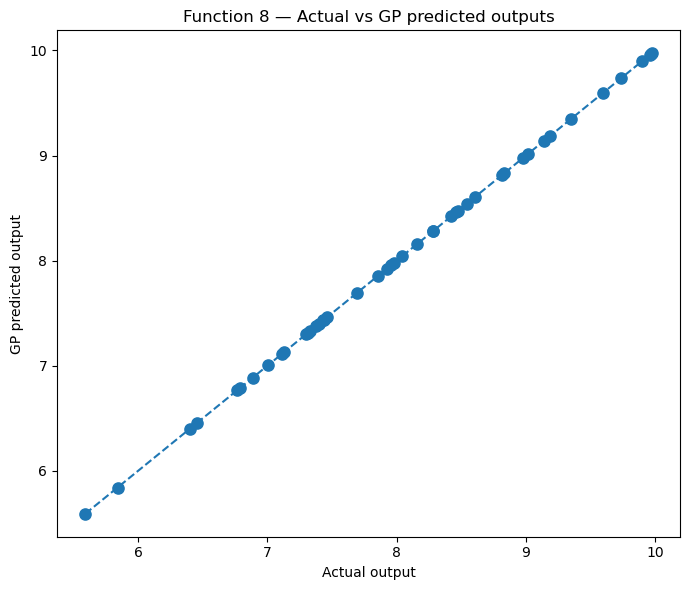

In [12]:
# ============================================================
# 12. FUNCTION 8 — GP DIAGNOSTIC
# ============================================================

training_predictions = gp.predict(X)

plt.figure(
    figsize=(7, 6)
)

plt.scatter(
    Y,
    training_predictions,
    s=65
)

minimum = min(
    Y.min(),
    training_predictions.min()
)

maximum = max(
    Y.max(),
    training_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual output")
plt.ylabel("GP predicted output")

plt.title(
    "Function 8 — Actual vs GP predicted outputs"
)

plt.tight_layout()
plt.show()